Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


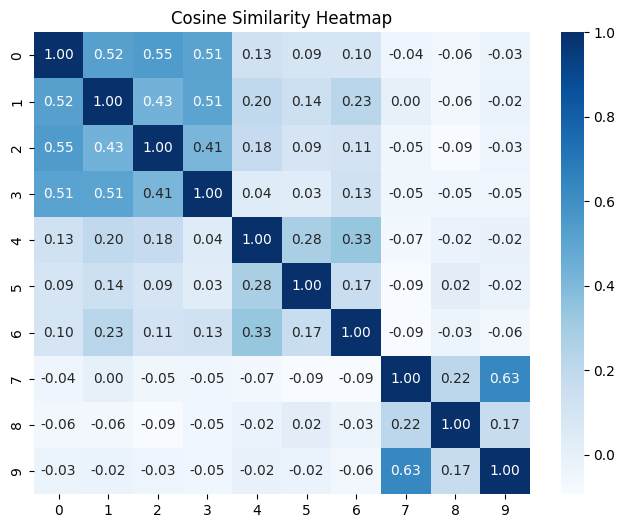

Query: The bowler took three wickets in one over

Sentence: The bowler took a wicket with a fast delivery.
Similarity score: 0.7205

Sentence: The batsman scored a century in the final match.
Similarity score: 0.5679



In [7]:
!pip install -q sentence-transformers seaborn

from sentence_transformers import SentenceTransformer, util
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 10 sentences in 3 topics

sentences = [
    "The batsman scored a century in the final match.",
    "The bowler took a wicket with a fast delivery.",
    "The team celebrated after winning the cricket tournament.",
    "The umpire gave the batsman out after a loud appeal.",

    "She cooked rice and curry for dinner.",
    "The chef baked a chocolate cake in the oven.",
    "He chopped vegetables before making the soup.",

    "Strong passwords help keep online accounts safe.",
    "We should not click on random emails and links.",
    "Using two-factor authentication makes accounts more secure."
]

topics = [
    "Cricket", "Cricket", "Cricket", "Cricket",
    "Cooking", "Cooking", "Cooking",
    "Cybersecurity", "Cybersecurity", "Cybersecurity"
]

data = pd.DataFrame({
    "Topic": topics,
    "Sentence": sentences
})

data

model = SentenceTransformer("all-MiniLM-L6-v2")
emb = model.encode(sentences, convert_to_tensor=True)

sim = util.cos_sim(emb, emb)
sim_df = pd.DataFrame(sim.cpu().numpy())

sim_df

plt.figure(figsize=(8,6))
sns.heatmap(sim_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cosine Similarity Heatmap")
plt.show()

query = "The bowler took three wickets in one over"

query_emb = model.encode(query, convert_to_tensor=True)
scores = util.cos_sim(query_emb, emb)[0]

result = pd.DataFrame({
    "Sentence": sentences,
    "Score": scores.cpu().numpy()
})

top2 = result.sort_values("Score", ascending=False).head(2)
top2

print("Query:", query)
print()

for i, row in top2.iterrows():
    print("Sentence:", row["Sentence"])
    print("Similarity score:", round(row["Score"], 4))
    print()
